# Ejercicio Fuzzy C-Means
Créditos: Página skfuzzy en https://pythonhosted.org/scikit-fuzzy

**Nota:** Hay que instalarse la libreria scikit-fuzzy que no viene por defecto en Anaconda. Para ello abrir una ventana de consola (ventana negra de windows) y hacer:
**conda install -c conda-forge scikit-fuzzy**


Vamos a hacer un ejercicio con datos sintéticos para el uso de Fuzzy C-Means. Para ello generaremos un conjunto de datos con tres clusters bien definidos, aunque en el desarrollo del ejecicio consideraremos que NO sabemos a priori nada de la estructura de los datos, y descubriremos la presencia de los tres clusters.

Importamos librerias y generamos los datos partiendo de  3 pares de estadísticos (media, desviación típica) añadiéndoles a éstos un ruido gaussiano. También puedes crear grupos de datos como en otras ocasiones usando la clase de scikit **sklearn.datasets.make_blobs**
Visualizaremos los grupos con la etiqueta propia de la función de distribución que los ha generado.

In [ ]:
!pip install scikit-fuzzy

Text(0.5, 1.0, 'Test data: 200 points x 3 clusters.')

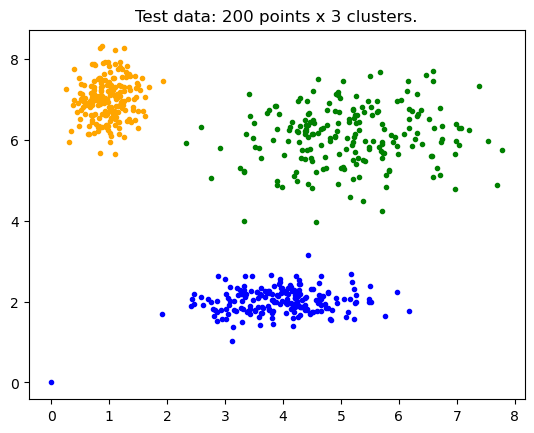

In [7]:

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz

colors = ['b', 'orange', 'g', 'r', 'c', 'm', 'y', 'k', 'Brown', 'ForestGreen']

# Define three cluster centers
centers = [[4, 2],
           [1, 7],
           [5, 6]]

# Define three cluster sigmas in x and y, respectively
sigmas = [[0.8, 0.3],
          [0.3, 0.5],
          [1.1, 0.7]]

# Generate test data
np.random.seed(42)  # Set seed for reproducibility
xpts = np.zeros(1)
ypts = np.zeros(1)
labels = np.zeros(1)
for i, ((xmu, ymu), (xsigma, ysigma)) in enumerate(zip(centers, sigmas)):
    xpts = np.hstack((xpts, np.random.standard_normal(200) * xsigma + xmu))
    ypts = np.hstack((ypts, np.random.standard_normal(200) * ysigma + ymu))
    labels = np.hstack((labels, np.ones(200) * i))

# Visualize the test data
fig0, ax0 = plt.subplots()
for label in range(3):
    ax0.plot(xpts[labels == label], ypts[labels == label], '.',
             color=colors[label])
ax0.set_title('Test data: 200 points x 3 clusters.')

**Ejercicio** ¿Entiendes el código de la caja anterior? Describe lo que hace

### Uso del Coeficiente de Particionamiento de Donne (FPC) para determinar el número de clusters.
Este coeficiente nos indica la calidad de un agrupamiento Fuzzy. Varía en valores entre 1/k y 1, donde k es el número de clusters. En su versión normalizada varía entre 0 y 1. Cuanto más cercano a 1 sea su valor, mejor es la calidad del agrupamiento. 
Vamos a usar este coeficiente para determinar el número adecuado de clusters. Para ello haremos varios Fuzzy-Cmeans con diferente número de clusters (de 2 a 11 clusters), calcularemos el coeficiente de partición de Donne y lo representaremos en una gráfica.

In [8]:
alldata = np.vstack((xpts, ypts))
fpcs = []

for ncenters in range(2,11):
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        alldata, ncenters, 2, error=0.005, maxiter=1000, init=None)

    # Store fpc values for later
    fpcs.append(fpc)


Text(0, 0.5, 'Fuzzy partition coefficient')

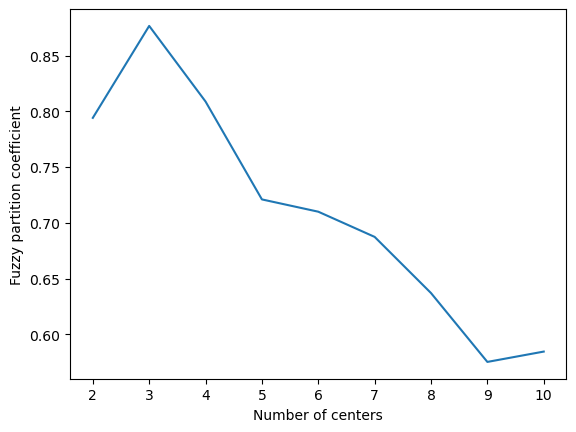

In [9]:
fig2, ax2 = plt.subplots()
ax2.plot(np.r_[2:11], fpcs)
ax2.set_xlabel("Number of centers")
ax2.set_ylabel("Fuzzy partition coefficient")

### Modelo Definitivo.
Podemos ver que el coeficiente de partición con valor más alto coincide con el número de 3 clusters.

Vamos a volver a generar un modelo con 3 clusters, que visualizaremos. Este agrupamiento puede variar respecto al que hemos hecho antes usando el 'ground truth' de las etiquetas de las distribuciones de probabilidad que los generaron. Piensa que, como K-Means, la inicialización es un problema en esta familia de Algoritmos.

**Ejercicio:** Consulta en la página de referencia https://pythonhosted.org/scikit-fuzzy/api/api.html  el método 'cmeans()' y escribe para el código de abajo (que usa cmeans) qué significado tienen sus argumentos y qué estructuras de datos devuelve.
Escríbelo aquí:



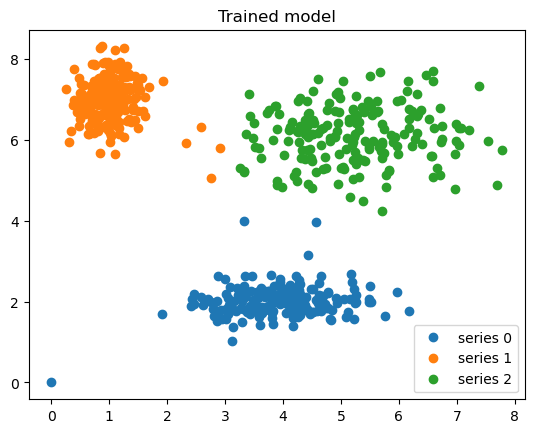

In [10]:
# Regenerate fuzzy model with 3 cluster centers - note that center ordering
# is random in this clustering algorithm, so the centers may change places
cntr, u_orig, _, _, _, _, _ = fuzz.cluster.cmeans(
    alldata, 3, 2, error=0.005, maxiter=1000)


# Show 3-cluster model
fig2, ax2 = plt.subplots()
ax2.set_title('Trained model')
for j in range(3):
    ax2.plot(alldata[0, u_orig.argmax(axis=0) == j],
             alldata[1, u_orig.argmax(axis=0) == j], 'o',
             label='series ' + str(j))
ax2.legend()

**Ejercicio:** Modifica el código anterior para poder obtener el Coeficiente de Partición de Donne e imprímelo y compáralo con el de la gráfica que obtuviste anteriormente.

Escribe aquí el valor que te sale y tu comentario sobre la comparación.



**Ejercicio** Consulta de la misma página el método 'cmeans_predict()' e indica sus argumentos usados en el código de la caja de abajo.
Escríbelo aquí:




Considera la instrucción de la caja de abajo 'cluster_membership = np.argmax(u, axis=0)'. Indica lo que hace.


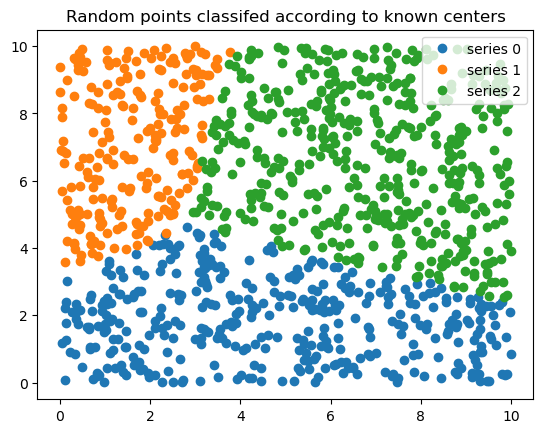

In [11]:
# Genera datos a partir de una distribución uniforme en el rango de valores [0, 10] en x y en y
newdata = np.random.uniform(0, 1, (1100, 2)) * 10

# Predice la pertenencia a los clusters usando `cmeans_predict` para el modelo de 3 clusters
u, u0, d, jm, p, fpc = fuzz.cluster.cmeans_predict(
    newdata.T, cntr, 2, error=0.005, maxiter=1000)


cluster_membership = np.argmax(u, axis=0)  

fig3, ax3 = plt.subplots()
ax3.set_title('Random points classifed according to known centers')
for j in range(3):
    ax3.plot(newdata[cluster_membership == j, 0],
             newdata[cluster_membership == j, 1], 'o',
             label='series ' + str(j))
ax3.legend()

plt.show()

### Predicción Fuzzy
**Ejercicio** Imagínate que representamos un mapa de Europa escalado dentro del cuadrado 10x10 de arriba. Y que los centroides de los tres clusters que has calculado (y que se encuentran en la variable 'centr')  señalan los núcleos de tres fenómenos atmosféricos. Concretamente centr[0] representa el núcleo de una tormenta tropical, centr[1] representa el núcleo de un anticiclón y centr[2] representa una borrasca. 
**Utiliza el método fuzz.cluster.cmeans_predict** para indicar cuál es la probabilidad en un pronóstico del tiempo de que la ciudad situada en las coordenadas del mapa (5,5) sufra las influencias de la tormenta, haga sol o bien haga lluvia.
Igualmente para una ciudad situada en (2,8) y otra en (9,4).

In [ ]:
#Pon tu código aquí

Escribe tus predicciones aquí:
    